<a href="https://colab.research.google.com/github/hkrishnanrt/DSA-Activities/blob/main/Unsupervised_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

In [ ]:
df =pd.read_csv('/content/adult_dataset.csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [ ]:
df.value_counts().sum()

np.int64(36859)

In [ ]:
df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
df=df.drop('income',axis=1)

In [ ]:
#Handling Missing values

from sklearn.impute import SimpleImputer

#missing columns
num_cols = ['age', 'hours-per-week']
cat_cols = ['workclass', 'occupation', 'native-country']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

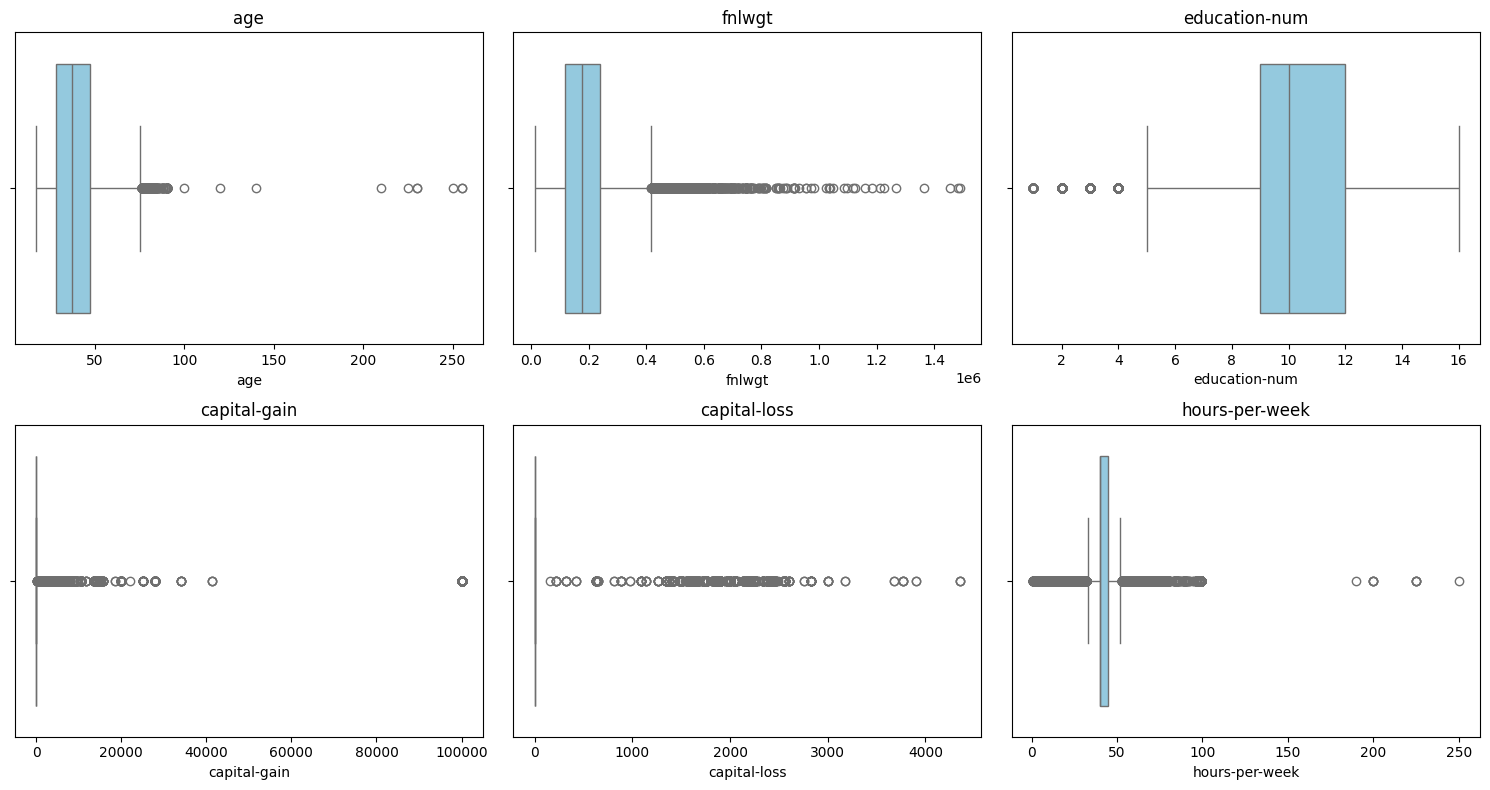

In [ ]:
# Checking for Outliers

# Plot boxplots
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()


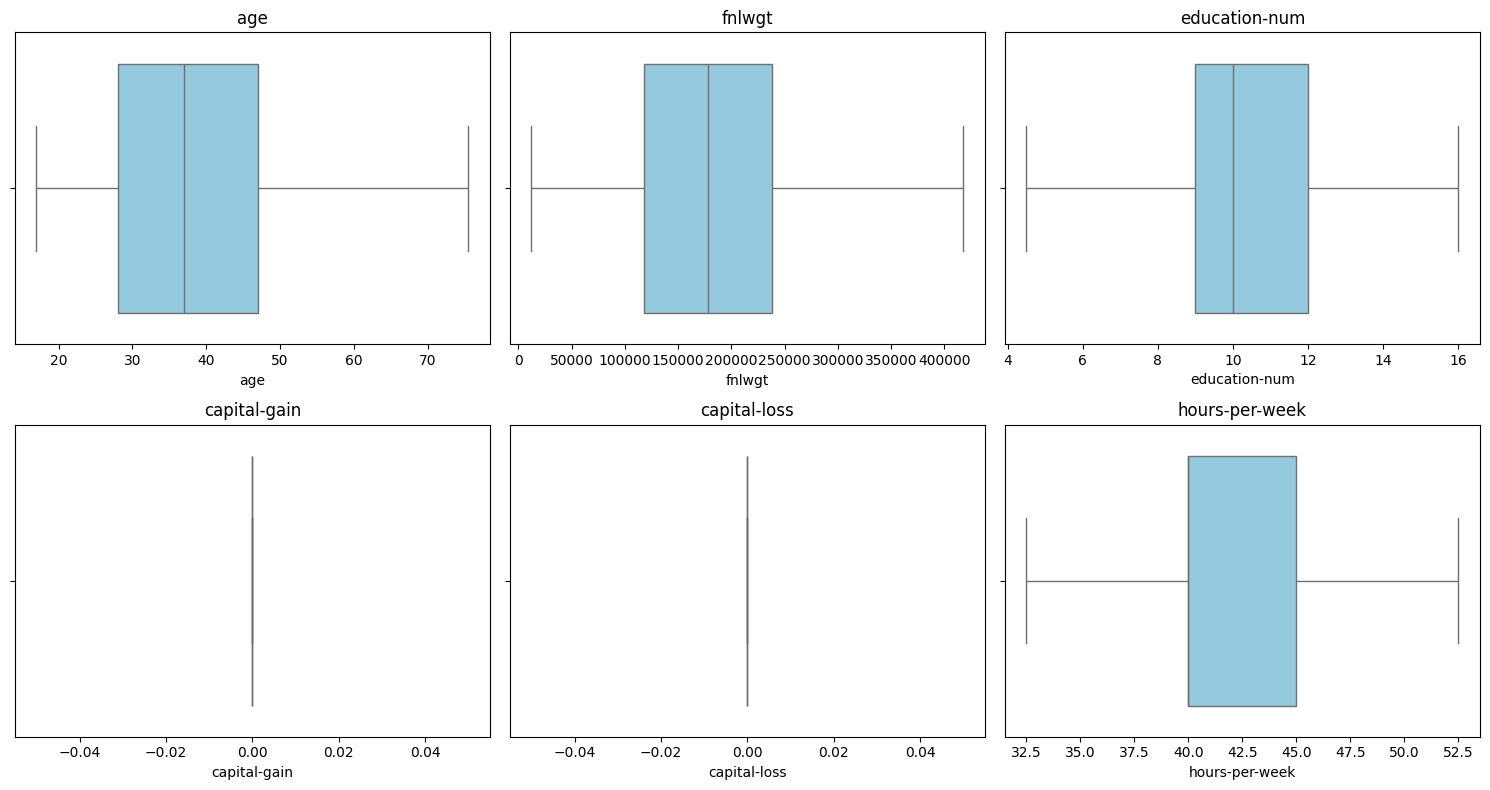

In [ ]:
#Handling Outliers

#Clipping using IQR
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR

  # Cap values beyond limits
  df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
  df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# Plot boxplots
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()


In [ ]:
#Finding Skewness

num_cols = df.select_dtypes(include=['number']).columns

skew_vals = df[num_cols].skew()
print(skew_vals)

age               0.530399
fnlwgt            0.555106
education-num    -0.035567
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.480552
dtype: float64


In [ ]:
# No need for Handling Skewness

In [ ]:
# from sklearn.preprocessing import PowerTransformer

# plt.figure(figsize=(12, 8))
# for i, col in enumerate(num_cols, 1):
#     plt.subplot(len(num_cols)//2 + 1, 2, i)
#     sns.histplot(df[col], kde=True, bins=30, color='teal')
#     plt.title(f'{col} (Skew={skew_vals[col]:.2f})')
# plt.tight_layout()
# plt.show()

In [ ]:
# # Fix skewness
# skew_vals = df[num_cols].skew()
# skewed_cols = skew_vals[abs(skew_vals) > 1].index
# print("Highly skewed columns:", skewed_cols.tolist())

In [ ]:
# # Apply PowerTransformer (handles zero/negative values)
# pt = PowerTransformer(method='yeo-johnson')
# df[skewed_cols] = pt.fit_transform(df[skewed_cols])


In [ ]:
# Separate numeric and categorical columns for preprocessing
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Transform the data
X_processed = preprocessor.fit_transform(df)

In [ ]:
#Checking for the suitable n cluster(k) value using Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)

wcss

[361755.34296469885,
 330339.6428163743,
 312167.0409810683,
 295444.94559551566,
 284628.50414681,
 272932.30846551876,
 265934.85243675724,
 260474.51661804155,
 256387.53520785455]

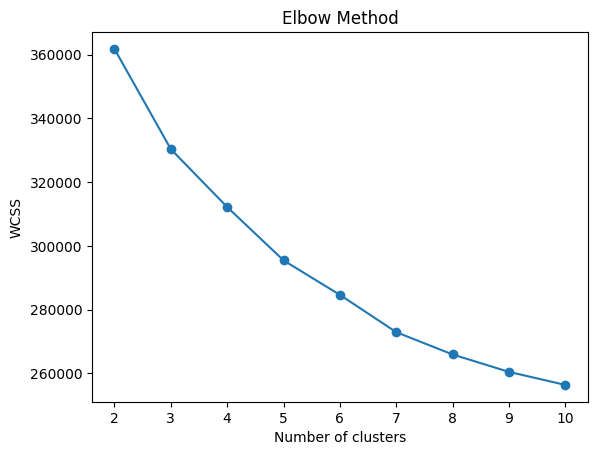

In [ ]:
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Using Elbow Method Found out that 4 might be the optimal k value

In [ ]:
# Finding Silhouette Score

from sklearn.metrics import silhouette_score

silhouette_scores = {}
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    sil = silhouette_score(X_processed, labels)
    silhouette_scores[k] = sil
    print(f"K={k}, Silhouette Score={sil:.3f}")

K=2, Silhouette Score=0.118
K=3, Silhouette Score=0.116
K=4, Silhouette Score=0.109
K=5, Silhouette Score=0.102
K=6, Silhouette Score=0.104


In [ ]:
# Finding out the Silhouette Score changes things we see that 2 has the highest score. So k=2 might be the optimal one

In [ ]:
# Reduce to 2D for plotting

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_processed)


In [ ]:
# Use Dendrogram to determine k

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_processed, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrogram')
plt.ylabel('Euclidean distance')
plt.show()

In [ ]:
# Pipeline for KMeans
kmeans_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=2, random_state=42))
])

# Pipeline for Agglomerative
agg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('agg', AgglomerativeClustering(n_clusters=2))
])

kmeans_labels = kmeans_pipeline.fit_predict(df)
agg_labels = agg_pipeline.fit_predict(df)

print("KMeans clusters:", np.unique(kmeans_labels))
print("Agglomerative clusters:", np.unique(agg_labels))

In [ ]:
# Create a DataFrame from the numerical columns for easier manipulation
df2 = pd.DataFrame(df[num_cols], columns=num_cols)

kmeans = KMeans(n_clusters=2,init='k-means++',random_state=42)
kmeans.fit(X_processed)
df2['Cluster'] = kmeans.predict(X_processed)
df2.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,Cluster
0,39.0,77516.0,13.0,0.0,0.0,40.0,1
1,50.0,83311.0,13.0,0.0,0.0,32.5,1
2,38.0,215646.0,9.0,0.0,0.0,40.0,0
3,53.0,234721.0,7.0,0.0,0.0,40.0,1
4,28.0,338409.0,13.0,0.0,0.0,40.0,0


In [ ]:
kmeans.labels_

array([1, 1, 0, ..., 1, 1, 1], dtype=int32)

In [ ]:
df2['Cluster'].value_counts()

,count
Cluster,
1,25785
0,23057


In [ ]:
kmeans.cluster_centers_

array([[-5.82470993e-01,  1.16284426e-01, -2.37076998e-01,
         0.00000000e+00,  0.00000000e+00, -4.72144731e-01,
         4.59924574e-02,  1.99835277e-02,  4.69894664e-02,
         3.90133946e-04,  8.10091465e-01,  8.75633968e-03,
         3.18175907e-02,  3.57622784e-02,  2.16741081e-04,
         3.87966535e-02,  5.74363865e-02,  1.98101348e-02,
         5.63526811e-03,  1.32645542e-02,  1.82929472e-02,
         2.06337509e-02,  3.20776800e-02,  3.75395552e-02,
         1.17560362e-01,  1.90732151e-03,  3.40413542e-01,
         2.20208938e-02,  2.38415189e-03,  2.81763405e-03,
         2.69409164e-01,  1.70141749e-01,  1.12705362e-03,
         1.11751701e-01,  1.72525901e-02,  6.24084269e-01,
         4.86366986e-02,  2.70059387e-02,  4.57757163e-02,
         1.62815900e-01,  3.03437514e-04,  8.21882180e-02,
         6.51957172e-02,  2.10672331e-02,  5.65260740e-02,
         6.46755386e-02,  1.55793489e-01,  7.93272357e-03,
         1.57874203e-01,  1.39147774e-02,  1.05032728e-0